In [1]:
import os
import json
import pandas as pd

OUTPUT_DIR = "/kaggle/working/"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
metadata_path = f"{OUTPUT_DIR}/metadata.json"

def create_metadata_from_parquet(train_path):
    df = pd.read_parquet(train_path)
    all_columns = df.columns.tolist()
    target_col = 'label'
    if target_col not in all_columns:
        raise ValueError(f"Target column '{target_col}' not found.")
    feature_cols = [col for col in all_columns if col != target_col]
    num_features = len(feature_cols)
    unique_labels = sorted(df[target_col].astype(str).unique())
    num_classes = len(unique_labels)
    label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
    id_to_label = {str(idx): label for idx, label in enumerate(unique_labels)}
    metadata = {
        "feature_cols": feature_cols,
        "target_col": target_col,
        "label_to_id": label_to_id,
        "id_to_label": id_to_label,
        "num_classes": num_classes,
        "num_features": num_features
    }
    return metadata

if not os.path.exists(metadata_path):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    metadata = create_metadata_from_parquet(TRAIN_PATH)
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"Metadata saved to {metadata_path}")
else:
    print("Metadata already exists.")

Metadata saved to /kaggle/working//metadata.json


In [2]:
# !mkdir /kaggle/working/training_checkpoints
# !cp /kaggle/input/datasets/truongdanghuy/aw-ssl-ckpt/training_checkpoints/* /kaggle/working/training_checkpoints/

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
import os

# =============================================================================
# CẤU HÌNH
# =============================================================================
NUM_FEATURES = 37
EMBEDDIM = 256
NUM_CLASSES = 8

# Đường dẫn file .pth (có thể là teacher_kd.pth hoặc ssl-cl-dnn-optuna-10-6.pth)
PTH_PATH = "/kaggle/input/models/truongdanghuy/ssl-cl-dnn/pytorch/default/4/teacher_ssl_dnn.pth"   # thay đổi nếu cần
OUTPUT_KERAS_PATH = "/kaggle/working/ssl_cl_dnn_teacher.keras"

# =============================================================================
# XÂY DỰNG KIẾN TRÚC MODEL
# =============================================================================
def build_encoder():
    inputs = tf.keras.Input(shape=(NUM_FEATURES,))
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(EMBEDDIM, activation='relu')(x)
    return Model(inputs, x, name='encoder')

def build_classifier():
    inputs = tf.keras.Input(shape=(EMBEDDIM,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(NUM_CLASSES, activation='linear')(x)   # logits
    return Model(inputs, x, name='classifier')

def build_full_teacher():
    encoder = build_encoder()
    classifier = build_classifier()
    inputs = encoder.input
    embeddings = encoder.output
    outputs = classifier(embeddings)
    model = Model(inputs, outputs, name='ssl_cl_dnn')
    return model, encoder, classifier

# =============================================================================
# HÀM LOAD TRỌNG SỐ TỪ PYTORCH (.pth) SANG KERAS
# =============================================================================
def load_pytorch_weights_to_keras(pth_path, keras_encoder, keras_classifier):
    """Load weights from PyTorch state_dict into Keras encoder and classifier."""
    state = torch.load(pth_path, map_location='cpu')
    
    # Lấy state_dict của encoder và classifier (có thể nằm trong 'encoder_state_dict', 'classifier_state_dict'
    # hoặc trực tiếp trong state['model'] tùy file)
    if 'encoder_state_dict' in state and 'classifier_state_dict' in state:
        enc_sd = state['encoder_state_dict']
        cls_sd = state['classifier_state_dict']
    elif 'model' in state:
        # Trường hợp file teacher_kd.pth chỉ có một state_dict
        enc_sd = {k.replace('encoder.', ''): v for k, v in state['model'].items() if k.startswith('encoder.')}
        cls_sd = {k.replace('classifier.', ''): v for k, v in state['model'].items() if k.startswith('classifier.')}
    else:
        raise ValueError("File .pth không có cấu trúc encoder_state_dict/classifier_state_dict hoặc model")
    
    def extract_weights(sd):
        """Trích xuất weight và bias theo thứ tự layer."""
        items = []
        for key, tensor in sd.items():
            # Tìm số thứ tự layer (dạng '0', '1', ...) trong key
            parts = key.split('.')
            layer_idx = None
            for p in parts:
                if p.isdigit():
                    layer_idx = int(p)
                    break
            if layer_idx is None:
                continue
            if 'weight' in key:
                items.append((layer_idx, 'weight', tensor))
            elif 'bias' in key:
                items.append((layer_idx, 'bias', tensor))
        items.sort(key=lambda x: x[0])
        weights = [t for (_, typ, t) in items if typ == 'weight']
        biases  = [t for (_, typ, t) in items if typ == 'bias']
        return weights, biases
    
    # Lấy danh sách Dense layer (bỏ qua InputLayer)
    enc_dense = [layer for layer in keras_encoder.layers if isinstance(layer, layers.Dense)]
    cls_dense = [layer for layer in keras_classifier.layers if isinstance(layer, layers.Dense)]
    
    # Load encoder
    enc_w, enc_b = extract_weights(enc_sd)
    for i, layer in enumerate(enc_dense):
        if i < len(enc_w):
            w = enc_w[i].numpy().T   # PyTorch (out, in) -> Keras (in, out)
            b = enc_b[i].numpy()
            layer.set_weights([w, b])
            print(f"[Encoder] Loaded layer {i}: {layer.name} shape {w.shape}")
        else:
            print(f"[Encoder] Warning: missing weight for layer {i}")
    
    # Load classifier
    cls_w, cls_b = extract_weights(cls_sd)
    for i, layer in enumerate(cls_dense):
        if i < len(cls_w):
            w = cls_w[i].numpy().T
            b = cls_b[i].numpy()
            layer.set_weights([w, b])
            print(f"[Classifier] Loaded layer {i}: {layer.name} shape {w.shape}")
        else:
            print(f"[Classifier] Warning: missing weight for layer {i}")
    
    print("✅ Weight loading completed.")

# =============================================================================
# XÂY DỰNG MODEL VÀ LOAD TRỌNG SỐ
# =============================================================================
print("Building teacher model...")
teacher_model, encoder, classifier = build_full_teacher()
teacher_model.summary()

print(f"\nLoading weights from: {PTH_PATH}")
load_pytorch_weights_to_keras(PTH_PATH, encoder, classifier)

# =============================================================================
# LƯU MODEL THÀNH FILE .KERAS
# =============================================================================
teacher_model.save(OUTPUT_KERAS_PATH)
print(f"\n✅ Teacher model saved to: {OUTPUT_KERAS_PATH}")
print(f"File size: {os.path.getsize(OUTPUT_KERAS_PATH) / (1024*1024):.2f} MB")

Building teacher model...


I0000 00:00:1786350478.937471      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786350478.940424      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ssl_cl_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Functional)         │ (None, 8)              │        67,848 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547,080 (2.09 MB)

 Trainable params: 547,080 (2.09 MB)

 Non-trainable params: 0 (0.00 B)


Loading weights from: /kaggle/input/models/truongdanghuy/ssl-cl-dnn/pytorch/default/4/teacher_ssl_dnn.pth
[Encoder] Loaded layer 0: dense shape (37, 512)
[Encoder] Loaded layer 1: dense_1 shape (512, 512)
[Encoder] Loaded layer 2: dense_2 shape (512, 256)
[Encoder] Loaded layer 3: dense_3 shape (256, 256)
[Classifier] Loaded layer 0: dense_4 shape (256, 256)
[Classifier] Loaded layer 1: dense_5 shape (256, 8)
✅ Weight loading completed.

✅ Teacher model saved to: /kaggle/working/ssl_cl_dnn_teacher.keras
File size: 2.12 MB


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 1: Imports & Config — AW-MTKD (Average-Weighted Multi-Teacher KD)
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import time
import xgboost as xgb

# Hyperparameters (giữ nguyên như bản CW-MTKD để so sánh công bằng giữa 2 biến thể)
BATCH_SIZE = 128
LEARNING_RATE = 0.005
EPOCHS = 50
TEMPERATURE = 2.0
ALPHA = 0.1
MAX_WEIGHT = 3.0          # trần cho class weight (biến thể "có class weight" được giữ lại)
M_TEACHERS = 2            # số teacher: CNN1D + XGBoost

# Paths (chỉnh lại theo môi trường của bạn)
OUTPUT_DIR = "/kaggle/working/"
METADATA_PATH = f"{OUTPUT_DIR}/metadata.json"
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"
TEST_PATH  = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
XGB_MODEL_PATH = "/kaggle/input/models/truongdanghuy/xgboost-model/keras/default/2/xgboost_best_teacher.json"
CNN_MODEL_PATH = "/kaggle/working/ssl_cl_dnn_teacher.keras"

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 2: Load Data + Class Weights (biến thể có class weight, capped tại MAX_WEIGHT)
# ──────────────────────────────────────────────────────────────────────────────
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
target_col = metadata['target_col']
num_classes = metadata['num_classes']
num_features = metadata['num_features']

df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
df_test  = pd.read_parquet(TEST_PATH)

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[target_col].values.astype(np.int32)
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val[target_col].values.astype(np.int32)
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test[target_col].values.astype(np.int32)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Number of classes: {num_classes}")

# Tính class weights dựa trên y_train (đã undersampled) — giữ nguyên biến thể class-weight
unique_classes = np.unique(y_train)
class_weights_raw = compute_class_weight('balanced', classes=unique_classes, y=y_train)
# Giới hạn weight tối đa = 3.0
class_weights = np.minimum(class_weights_raw, MAX_WEIGHT)

print("Class counts:", np.bincount(y_train))
print(f"Class weights (capped at {MAX_WEIGHT}):", class_weights)

# Chuyển thành tensor để dùng trong loss
class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)


Train: (4468344, 37), Val: (1117087, 37), Test: (1396358, 37)
Number of classes: 8
Class counts: [ 670231 1916729  619802    8013  278953  383443   15173  576000]
Class weights (capped at 3.0): [0.83335895 0.29140426 0.9011636  3.         2.00228354 1.45665197
 3.         0.96969271]


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 3: Load Teacher Models (CNN1D + XGBoost) — không đổi so với bản CW-MTKD
# ──────────────────────────────────────────────────────────────────────────────
# XGBoost (outputs probabilities)
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(XGB_MODEL_PATH)

# CNN1D (outputs logits)
cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 4: Build Student Model (MLP 64-32, outputs logits) — giữ nguyên kiến trúc
# ──────────────────────────────────────────────────────────────────────────────
def build_student(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='linear')   # logits
    ])
    return model

student = build_student(num_features, num_classes)
student.summary()
print(f"Student parameters: {student.count_params()}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,776 (18.66 KB)

 Trainable params: 4,776 (18.66 KB)

 Non-trainable params: 0 (0.00 B)

Student parameters: 4776


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 5: Precompute XGBoost probabilities & Create tf.data.Datasets
# ──────────────────────────────────────────────────────────────────────────────
print("Precomputing XGBoost probabilities...")
xgb_probs_train = xgb_model.predict_proba(X_train).astype(np.float32)
xgb_probs_val   = xgb_model.predict_proba(X_val).astype(np.float32)
xgb_probs_test  = xgb_model.predict_proba(X_test).astype(np.float32)

print(f"Train shape: {xgb_probs_train.shape}, Val shape: {xgb_probs_val.shape}")

# Tạo dataset kèm theo probs đã precompute
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, xgb_probs_train)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset   = tf.data.Dataset.from_tensor_slices((X_val, y_val, xgb_probs_val)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset  = tf.data.Dataset.from_tensor_slices((X_test, y_test, xgb_probs_test)) \
                              .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Precomputing XGBoost probabilities...
Train shape: (4468344, 8), Val shape: (1117087, 8)


In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 6: AW-MTKD — Average-Weighted Fusion + Loss Function (Algorithm 1)
# ──────────────────────────────────────────────────────────────────────────────
# Khác biệt duy nhất so với CW-MTKD (Algorithm 2) nằm ở bước fusion:
#   CW-MTKD: w_k = c_k / sum(c_m)          (trọng số theo confidence, tính lại mỗi batch)
#   AW-MTKD: w_k = 1 / M với mọi k          (trọng số cố định, đồng đều — Algorithm 1, dòng 8)
# => KHÔNG cần bước tính confidence score (Algorithm 2, dòng 4-10) nữa.
# Phần hard-loss (có class weight), KD-loss (KL nhân T^2), và cách cập nhật student
# được giữ nguyên 100% so với bản CW-MTKD để đảm bảo so sánh công bằng.

GRAD_CLIP_NORM = 1.0
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)

@tf.function
def train_step(x_batch, y_batch, xgb_probs_batch):
    # ---- Teacher 1: CNN1D (logits -> softmax với temperature) ----
    cnn_logits = cnn_model(x_batch, training=False)
    cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)

    # ---- Teacher 2: XGBoost (probabilities precomputed -> temperature scaling) ----
    xgb_probs_scaled = xgb_probs_batch ** (1.0 / TEMPERATURE)
    xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)

    teacher_probs = [cnn_probs, xgb_probs_scaled]

    # ---- AW-MTKD fusion: p_fused = (1/M) * sum_k p^k(T)  (Algorithm 1, dòng 8) ----
    fused = tf.add_n(teacher_probs) / float(M_TEACHERS)

    with tf.GradientTape() as tape:
        student_logits = student(x_batch, training=True)

        # Hard loss (CE) với class weights — giữ nguyên biến thể class-weight (max=3.0)
        hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=y_batch, logits=student_logits
        )
        sample_weights = tf.gather(class_weights_tensor, y_batch)
        hard_loss = tf.reduce_mean(hard_loss_per_sample * sample_weights)

        # KD loss: tau^2 * KL(p_fused || student_probs)
        student_probs = tf.nn.softmax(student_logits / TEMPERATURE)
        kd_loss = tf.reduce_mean(
            tf.reduce_sum(fused * tf.math.log(fused / (student_probs + 1e-8)), axis=1)
        ) * (TEMPERATURE ** 2)

        loss = (1 - ALPHA) * hard_loss + ALPHA * kd_loss

    grads = tape.gradient(loss, student.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP_NORM)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss


def compute_val_loss_and_fused(x_batch, y_batch, xgb_probs_batch):
    """Dùng lại đúng công thức AW-MTKD cho vòng validation (không backprop)."""
    cnn_logits = cnn_model(x_batch, training=False)
    cnn_probs = tf.nn.softmax(cnn_logits / TEMPERATURE)

    xgb_probs_scaled = xgb_probs_batch ** (1.0 / TEMPERATURE)
    xgb_probs_scaled = xgb_probs_scaled / tf.reduce_sum(xgb_probs_scaled, axis=1, keepdims=True)

    teacher_probs = [cnn_probs, xgb_probs_scaled]
    fused = tf.add_n(teacher_probs) / float(M_TEACHERS)

    student_logits = student(x_batch, training=False)
    hard_loss_per_sample = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=y_batch, logits=student_logits
    )
    sample_weights = tf.gather(class_weights_tensor, y_batch)
    hard_loss = tf.reduce_mean(hard_loss_per_sample * sample_weights)

    student_probs = tf.nn.softmax(student_logits / TEMPERATURE)
    kd_loss = tf.reduce_mean(
        tf.reduce_sum(fused * tf.math.log(fused / (student_probs + 1e-8)), axis=1)
    ) * (TEMPERATURE ** 2)

    loss_val = (1 - ALPHA) * hard_loss + ALPHA * kd_loss
    return loss_val, student_logits


In [10]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 7: Training Loop (checkpoint resume, ReduceLROnPlateau) — AW-MTKD
# ──────────────────────────────────────────────────────────────────────────────
import pickle
import shutil
from tqdm.auto import tqdm

CHECKPOINT_DIR = f"{OUTPUT_DIR}/training_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
METADATA_FILE = f"{CHECKPOINT_DIR}/metadata.pkl"

def save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights):
    metadata = {
        'epoch': epoch,
        'best_val_loss': best_val_loss,
        'wait_lr': wait_lr,
        'current_lr': current_lr,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'best_weights': best_weights
    }
    with open(METADATA_FILE, 'wb') as f:
        pickle.dump(metadata, f)

def load_metadata():
    if not os.path.exists(METADATA_FILE):
        return None, 0
    with open(METADATA_FILE, 'rb') as f:
        metadata = pickle.load(f)
    return metadata, metadata['epoch']

# Checkpoint object (lưu model + optimizer)
checkpoint = tf.train.Checkpoint(model=student, optimizer=optimizer)
checkpoint_manager = tf.train.CheckpointManager(
    checkpoint,
    directory=CHECKPOINT_DIR,
    max_to_keep=2
)

# Load metadata và checkpoint nếu có (cho phép resume training)
metadata, start_epoch = load_metadata()
if metadata is not None:
    print(f"Resuming from epoch {start_epoch}")
    best_val_loss = metadata['best_val_loss']
    wait_lr = metadata['wait_lr']
    current_lr = metadata['current_lr']
    train_losses = metadata['train_losses']
    val_losses = metadata['val_losses']
    train_accuracies = metadata['train_accuracies']
    val_accuracies = metadata['val_accuracies']
    best_weights = metadata['best_weights']
    latest_checkpoint = tf.train.latest_checkpoint(CHECKPOINT_DIR)
    if latest_checkpoint is not None:
        checkpoint.restore(latest_checkpoint).expect_partial()
        print(f"  ✅ Restored model and optimizer from {latest_checkpoint}")
    else:
        print("  ⚠️  No checkpoint file found, but metadata exists. Starting fresh.")
    epoch_start = start_epoch + 1
else:
    print("Starting fresh training")
    best_val_loss = float('inf')
    best_weights = None
    wait_lr = 0
    current_lr = LEARNING_RATE
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    epoch_start = 1

# Tham số ReduceLROnPlateau
patience_lr = 5
lr_factor = 0.5
min_lr = 1e-4

# Vòng lặp training
for epoch in range(epoch_start, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS} (LR = {current_lr:.6f})")
    epoch_loss = 0.0
    num_batches = 0

    # Training
    pbar = tqdm(train_dataset, desc="Training", unit="batch")
    for x_batch, y_batch, xgb_probs_batch in pbar:
        loss = train_step(x_batch, y_batch, xgb_probs_batch)
        epoch_loss += loss.numpy()
        num_batches += 1
        pbar.set_postfix({"loss": f"{loss.numpy():.4f}"})

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)

    # Train accuracy
    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    for x_batch, y_batch, _ in train_dataset:
        student_logits = student(x_batch, training=False)
        train_acc_metric.update_state(y_batch, student_logits)
    train_acc = train_acc_metric.result().numpy()
    train_accuracies.append(train_acc)

    # Validation
    val_loss_epoch = 0.0
    val_num_batches = 0
    val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

    for x_batch, y_batch, xgb_probs_batch in val_dataset:
        loss_val, student_logits = compute_val_loss_and_fused(x_batch, y_batch, xgb_probs_batch)
        val_loss_epoch += loss_val.numpy()
        val_num_batches += 1
        val_acc_metric.update_state(y_batch, student_logits)

    avg_val_loss = val_loss_epoch / val_num_batches
    val_losses.append(avg_val_loss)
    val_acc = val_acc_metric.result().numpy()
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Lưu checkpoint (model + optimizer)
    checkpoint_manager.save()
    print(f"  💾 Checkpoint saved at epoch {epoch}")

    # Lưu metadata
    save_metadata(epoch, best_val_loss, wait_lr, current_lr,
                  train_losses, val_losses, train_accuracies, val_accuracies, best_weights)

    # ModelCheckpoint (best theo val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_weights = student.get_weights()
        student.save("/kaggle/working/student_best.keras")
        print(f"  ✅ New best model saved with val_loss = {avg_val_loss:.6f}")
        wait_lr = 0
    else:
        wait_lr += 1

    # ReduceLROnPlateau
    if wait_lr >= patience_lr and current_lr > min_lr:
        current_lr = max(current_lr * lr_factor, min_lr)
        if hasattr(optimizer.learning_rate, 'assign'):
            optimizer.learning_rate.assign(current_lr)
        else:
            optimizer.learning_rate = current_lr
        wait_lr = 0
        print(f"  🔻 Learning rate reduced to {current_lr:.6f}")

# Restore best weights
if best_weights is not None:
    student.set_weights(best_weights)
    print(f"\nRestored best model with val_loss = {best_val_loss:.6f}")

# Xóa checkpoint
shutil.rmtree(CHECKPOINT_DIR, ignore_errors=True)
print("Checkpoints cleaned up.")
print("Training completed!")


Starting fresh training

Epoch 1/50 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 1 | Train Loss: 0.3925 | Val Loss: 0.3502 | Train Acc: 0.7822 | Val Acc: 0.7820
  💾 Checkpoint saved at epoch 1
  ✅ New best model saved with val_loss = 0.350182

Epoch 2/50 (LR = 0.005000)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 2 | Train Loss: 0.3492 | Val Loss: 0.3485 | Train Acc: 0.7900 | Val Acc: 0.7899
  💾 Checkpoint saved at epoch 2
  ✅ New best model saved with val_loss = 0.348461

Epoch 3/50 (LR = 0.005000)


...

Epoch 48 | Train Loss: 0.3033 | Val Loss: 0.3013 | Train Acc: 0.8189 | Val Acc: 0.8186
  💾 Checkpoint saved at epoch 48
  ✅ New best model saved with val_loss = 0.301298

Epoch 49/50 (LR = 0.002500)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 49 | Train Loss: 0.3025 | Val Loss: 0.3034 | Train Acc: 0.8209 | Val Acc: 0.8205
  💾 Checkpoint saved at epoch 49

Epoch 50/50 (LR = 0.002500)


Training:   0%|          | 0/34909 [00:00<?, ?batch/s]

Epoch 50 | Train Loss: 0.3020 | Val Loss: 0.3011 | Train Acc: 0.8207 | Val Acc: 0.8202
  💾 Checkpoint saved at epoch 50
  ✅ New best model saved with val_loss = 0.301150

Restored best model with val_loss = 0.301150
Checkpoints cleaned up.
Training completed!


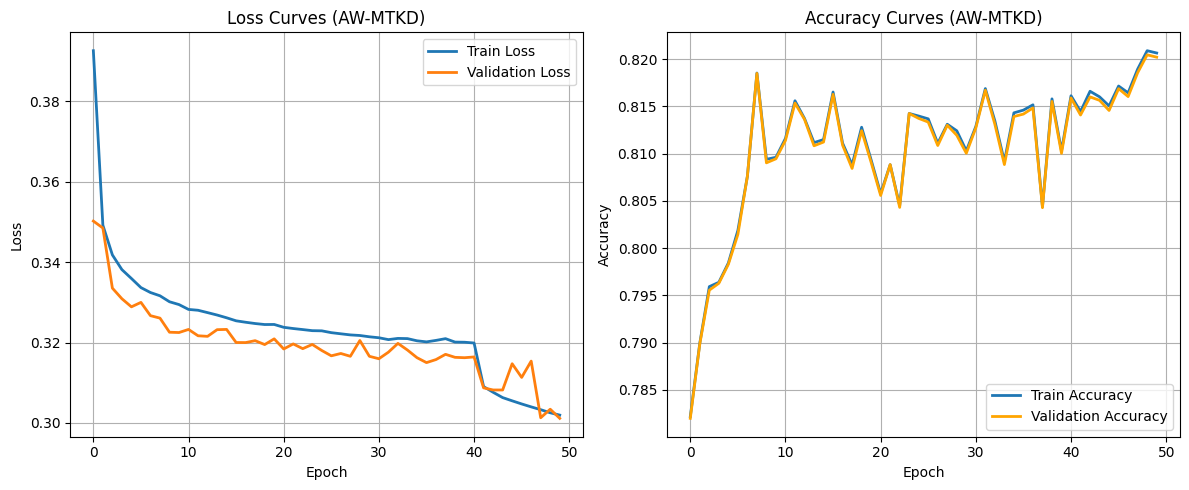

In [11]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 8: Plot Training Curves (train/val loss và train/val accuracy) — không đổi
# ──────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves (AW-MTKD)')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2, color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves (AW-MTKD)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves_aw_mtkd.png", dpi=150)
plt.show()


  103/10910 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step

I0000 00:00:1786382972.683325      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10910/10910 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
===== Classification Report (AW-MTKD) =====
              precision    recall  f1-score   support

           0       0.84      0.82      0.83    209448
           1       0.95      0.77      0.85    598978
           2       0.55      0.87      0.67    193688
           3       0.61      0.29      0.39      2504
           4       0.87      0.85      0.86     87173
           5       0.69      0.79      0.73    119826
           6       0.60      0.11      0.18      4741
           7       1.00      0.99      1.00    180000

    accuracy                           0.82   1396358
   macro avg       0.76      0.68      0.69   1396358
weighted avg       0.85      0.82      0.83   1396358



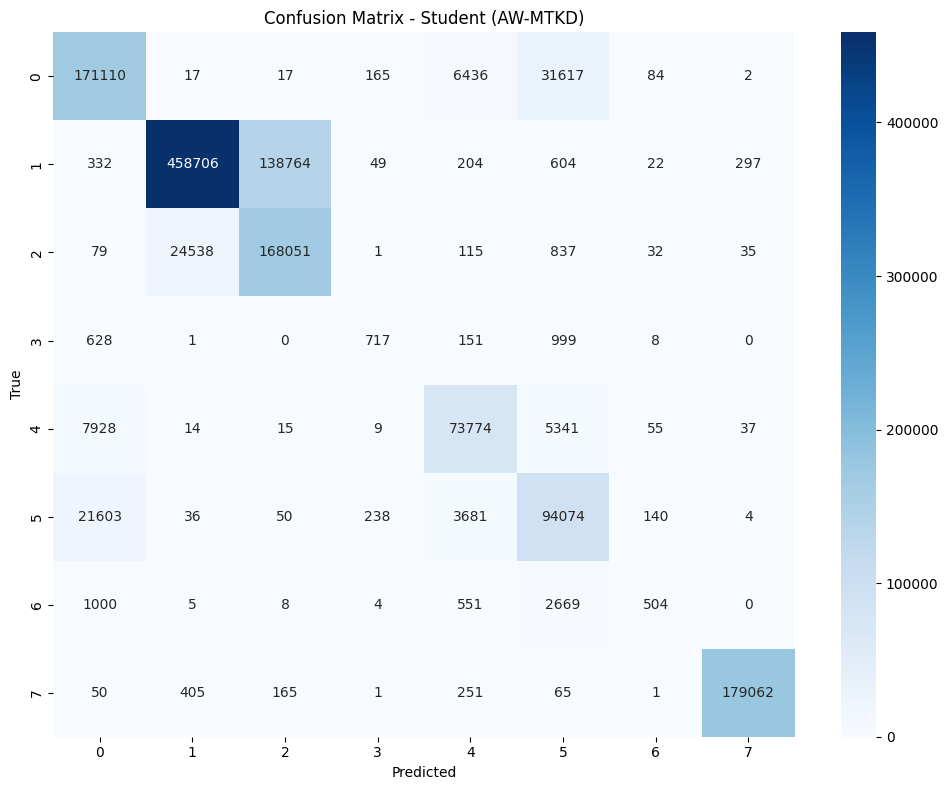

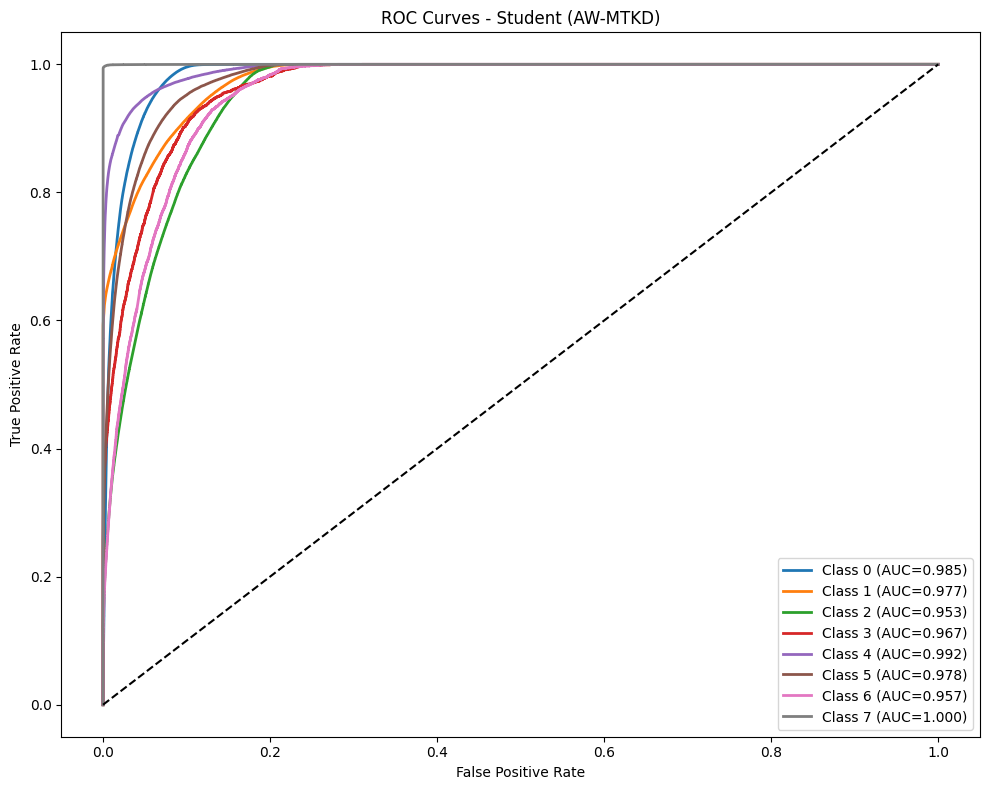

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 9: Evaluation on Test Set — giữ nguyên các đánh giá như bản CW-MTKD
# ──────────────────────────────────────────────────────────────────────────────
test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_logits, axis=1)
test_probs = tf.nn.softmax(test_logits).numpy()

print("===== Classification Report (AW-MTKD) =====")
print(classification_report(y_test, test_preds, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Student (AW-MTKD)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_aw_mtkd.png", dpi=150)
plt.show()

# ROC Curves
y_bin = label_binarize(y_test, classes=range(num_classes))
plt.figure(figsize=(10,8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={auc(fpr, tpr):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Student (AW-MTKD)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves_aw_mtkd.png", dpi=150)
plt.show()


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL 10: Heaviness Metrics (Model Size, Params, FLOPs, Inference Time) — không đổi
# ──────────────────────────────────────────────────────────────────────────────
# Model size
student.save("temp_student.keras")
size_mb = os.path.getsize("temp_student.keras") / (1024*1024)
os.remove("temp_student.keras")
print(f"Model size: {size_mb:.4f} MB")
print(f"Total parameters: {student.count_params()}")

# Approximate FLOPs
def approx_flops(model):
    total = 0
    for layer in model.layers:
        if len(layer.weights) > 0:  # Dense layers có weights
            kernel = layer.weights[0]  # shape (input_dim, output_dim)
            input_dim = kernel.shape[0]
            output_dim = kernel.shape[1]
            total += input_dim * output_dim + output_dim  # phép nhân + bias
    return total

print(f"FLOPs per sample (approx): {approx_flops(student)}")

# Inference time
N = 2000
start = time.perf_counter()
student.predict(X_test[:N], batch_size=BATCH_SIZE, verbose=0)
inf_time = (time.perf_counter() - start) / N * 1000  # ms per sample
print(f"Inference time per sample: {inf_time:.4f} ms")


Model size: 0.0358 MB
Total parameters: 4776
FLOPs per sample (approx): 4776
Inference time per sample: 0.1940 ms


10910/10910 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step

CLASSIFICATION REPORT (digits=4)
              precision    recall  f1-score   support

           0     0.8440    0.8170    0.8303    209448
           1     0.9483    0.7658    0.8473    598978
           2     0.5473    0.8676    0.6712    193688
           3     0.6056    0.2863    0.3888      2504
           4     0.8663    0.8463    0.8562     87173
           5     0.6907    0.7851    0.7349    119826
           6     0.5957    0.1063    0.1804      4741
           7     0.9979    0.9948    0.9963    180000

    accuracy                         0.8207   1396358
   macro avg     0.7620    0.6837    0.6882   1396358
weighted avg     0.8544    0.8207    0.8274   1396358


----------------------------------------
Macro AUC   : 0.9761
Weighted AUC: 0.9788
Micro AUC   : 0.9884
----------------------------------------


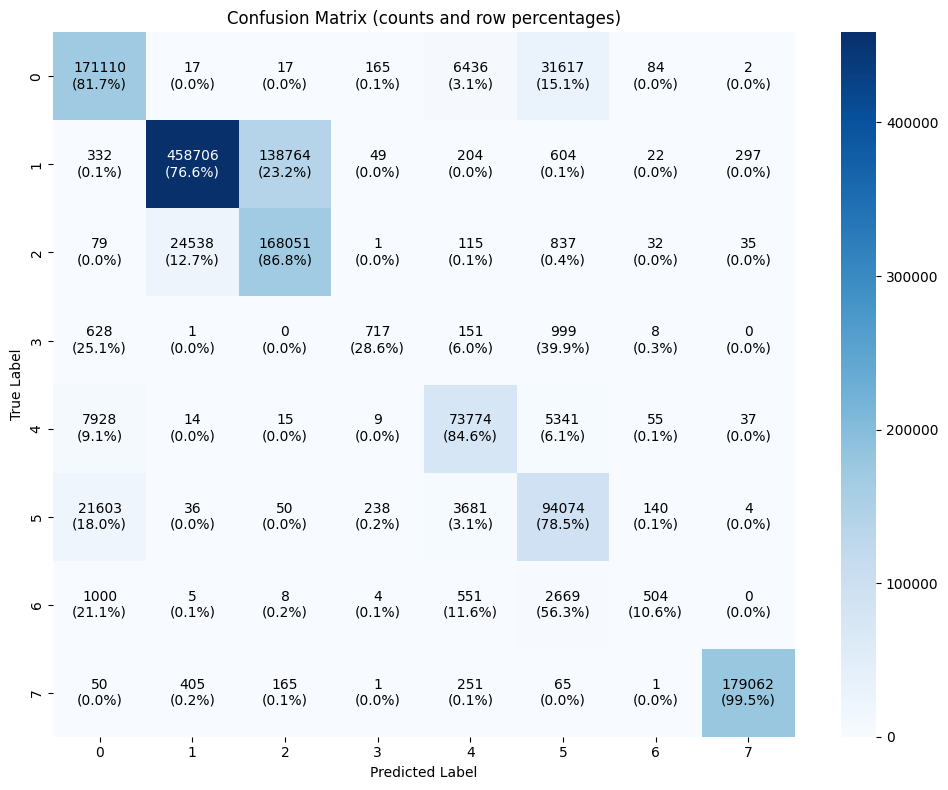

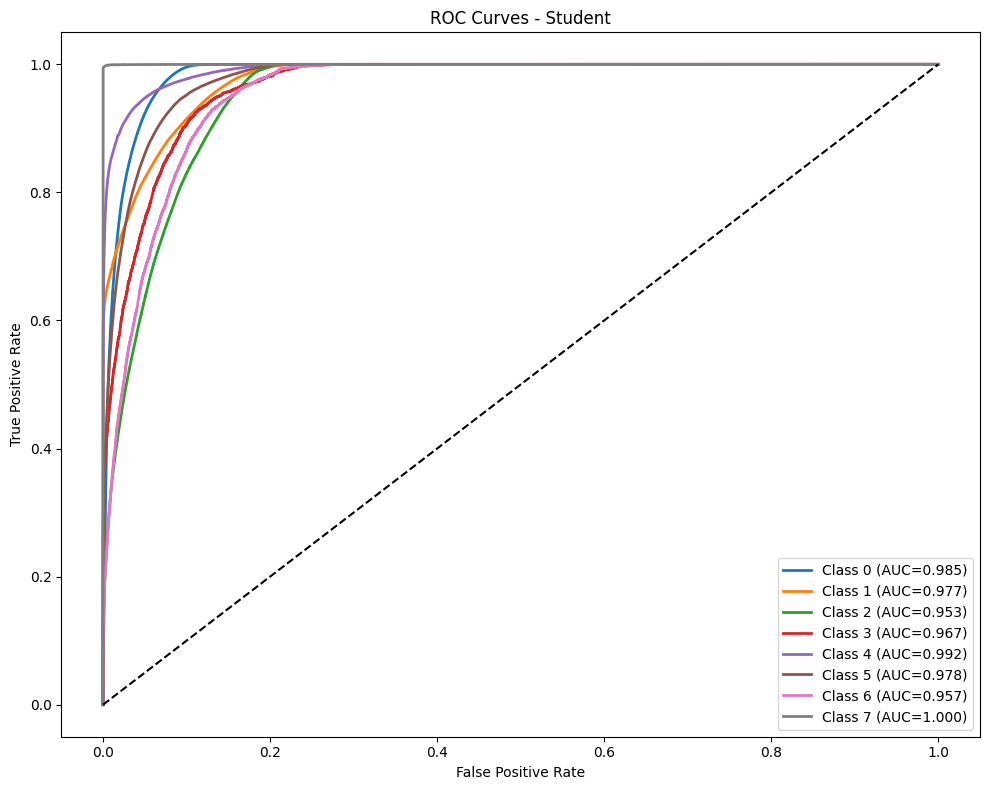

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# CELL: Evaluation (có thể chạy độc lập hoặc sau khi train)
# ──────────────────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Cấu hình -----
# Đường dẫn đến model đã train (dùng khi chạy độc lập)
MODEL_PATH = "/kaggle/working/student_best.keras"      # File model tốt nhất từ training
METADATA_PATH = "/kaggle/working/metadata.json"
TEST_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
BATCH_SIZE = 128
OUTPUT_DIR = "/kaggle/working/"   # Thư mục output để lưu ảnh

# ----- 1. Load metadata -----
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)
num_classes = metadata['num_classes']
feature_cols = metadata['feature_cols']
target_col = metadata['target_col']

# ----- 2. Load model (nếu chưa có sẵn) -----
try:
    # Nếu biến 'student' đã tồn tại (từ training), dùng nó
    student
except NameError:
    print("Loading model from file...")
    student = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded.")

# ----- 3. Load dữ liệu test -----
df_test = pd.read_parquet(TEST_PATH)
X_test = df_test[feature_cols].values.astype(np.float32)
y_test = df_test[target_col].values.astype(np.int32)

# ----- 4. Dự đoán -----
test_logits = student.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_preds = np.argmax(test_logits, axis=1)
test_probs = tf.nn.softmax(test_logits).numpy()

# ----- 5. Classification Report với 4 số thập phân -----
print("\n" + "="*60)
print("CLASSIFICATION REPORT (digits=4)")
print("="*60)
print(classification_report(y_test, test_preds, digits=4, zero_division=0))

# ----- 6. AUC (macro, weighted, micro) -----
y_bin = label_binarize(y_test, classes=range(num_classes))
auc_macro = roc_auc_score(y_bin, test_probs, average='macro', multi_class='ovr')
auc_weighted = roc_auc_score(y_bin, test_probs, average='weighted', multi_class='ovr')
auc_micro = roc_auc_score(y_bin, test_probs, average='micro', multi_class='ovr')
print("\n" + "-"*40)
print(f"Macro AUC   : {auc_macro:.4f}")
print(f"Weighted AUC: {auc_weighted:.4f}")
print(f"Micro AUC   : {auc_micro:.4f}")
print("-"*40)

# ----- 7. Confusion Matrix với count và % theo hàng -----
cm = confusion_matrix(y_test, test_preds)
# Tính phần trăm theo hàng (mỗi hàng = nhãn thực tế)
cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)

# Thêm annotation thủ công (count + percentage)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_percent[i, j]
        # Chọn màu chữ tương phản
        color = 'white' if count > cm.max() * 0.4 else 'black'
        plt.text(j + 0.5, i + 0.5, f"{count}\n({pct:.1f}%)",
                 ha='center', va='center', color=color, fontsize=10)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (counts and row percentages)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_with_pct.png", dpi=150)
plt.show()

# ----- 8. ROC curves (tùy chọn) -----
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], test_probs[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC={roc_auc_score(y_bin[:, i], test_probs[:, i]):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Student')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curves.png", dpi=150)
plt.show()